In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [4]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
print('Number of null values in each column:')
print(df.isnull().sum())

Number of null values in each column:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


It appears there are null values in `Preparation_Time_min` and `Courier_Experience_yrs`. Since these are numerical columns, I will fill the missing values with the mean of their respective columns to maintain the overall distribution. For categorical columns, if any had missing values, I would typically fill them with the mode.

In [7]:
# Fill missing numerical values with the mean, addressing the FutureWarning
for col in ['Preparation_Time_min', 'Courier_Experience_yrs']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Fill missing categorical values with the mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify that there are no more null values
print('Number of null values after imputation:')
print(df.isnull().sum())

Number of null values after imputation:
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


Now that the null values have been handled, the dataset is ready for further analysis.

In [8]:
df = df.drop('Order_ID', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Distance_km             1000 non-null   float64
 1   Weather                 1000 non-null   object 
 2   Traffic_Level           1000 non-null   object 
 3   Time_of_Day             1000 non-null   object 
 4   Vehicle_Type            1000 non-null   object 
 5   Preparation_Time_min    1000 non-null   int64  
 6   Courier_Experience_yrs  1000 non-null   float64
 7   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [9]:
df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


### 3. Categorical Features Analysis

Let's analyze the categorical features: `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type`. We will look at their distributions and how they relate to the `Delivery_Time_min`.

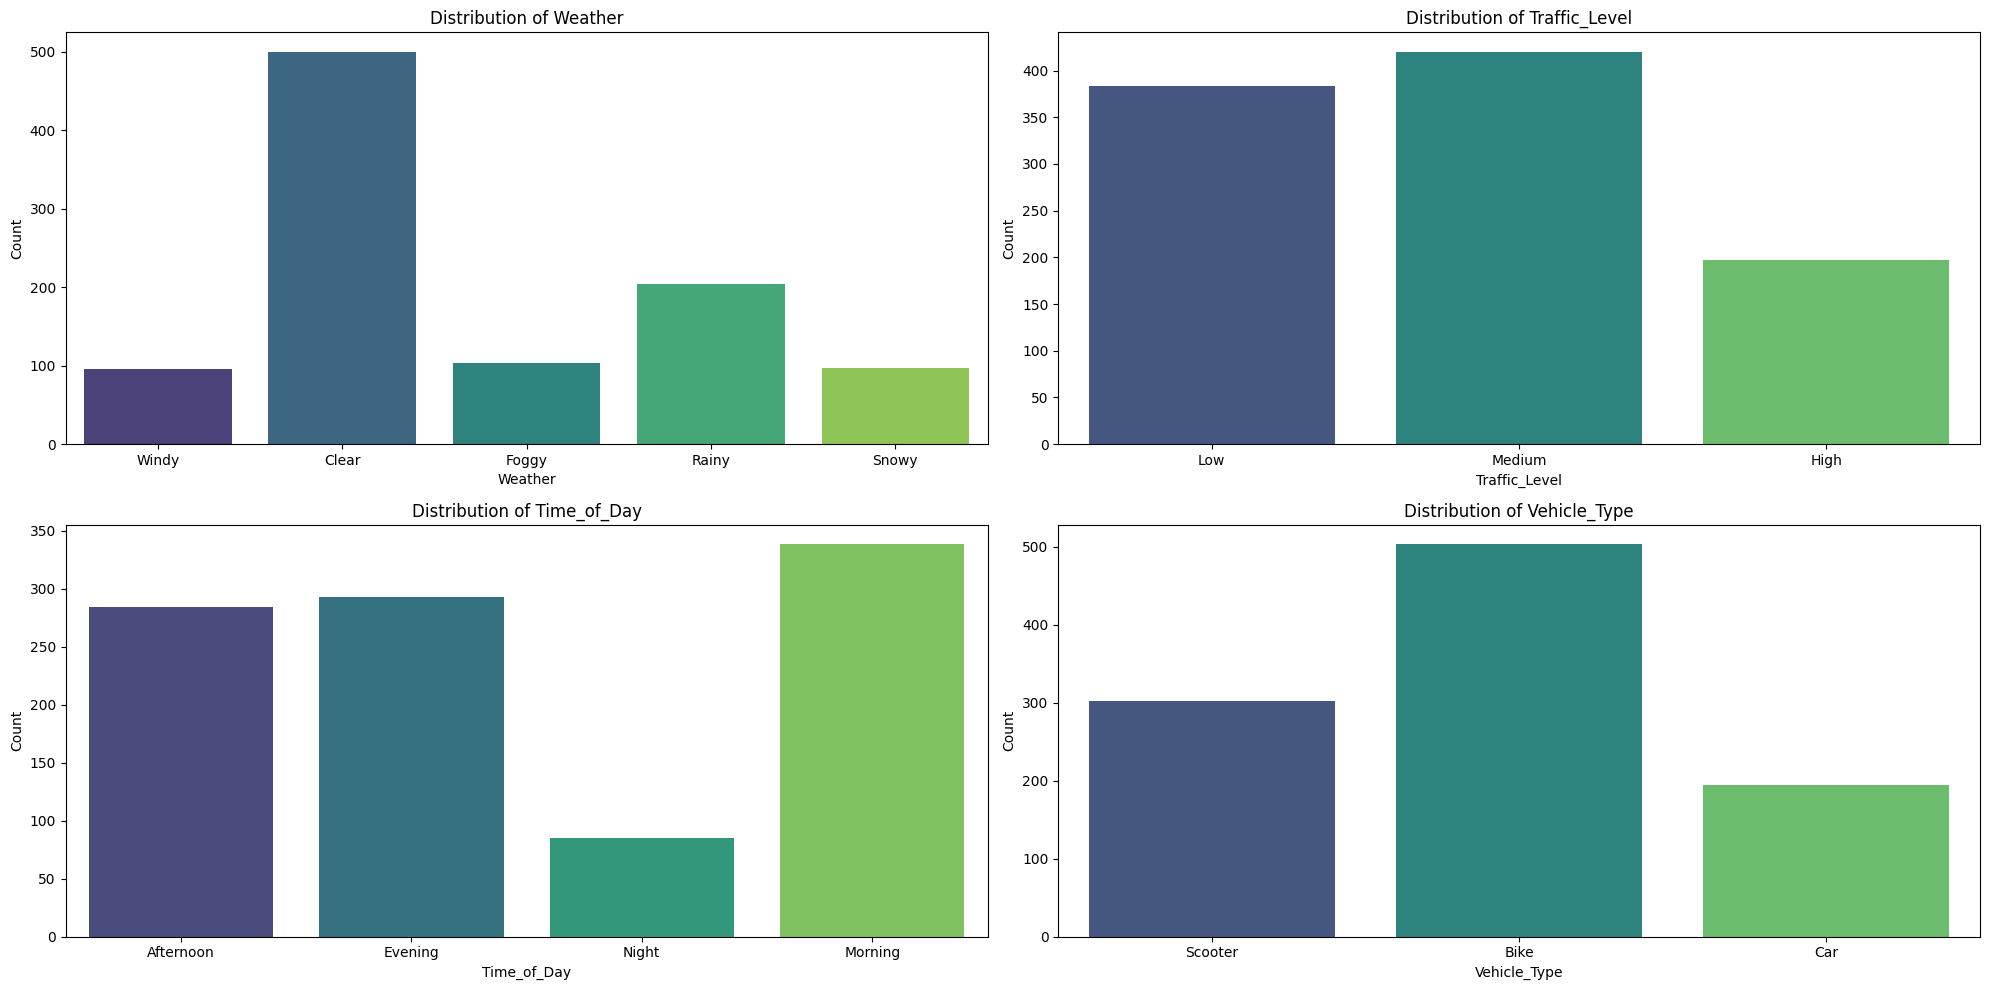

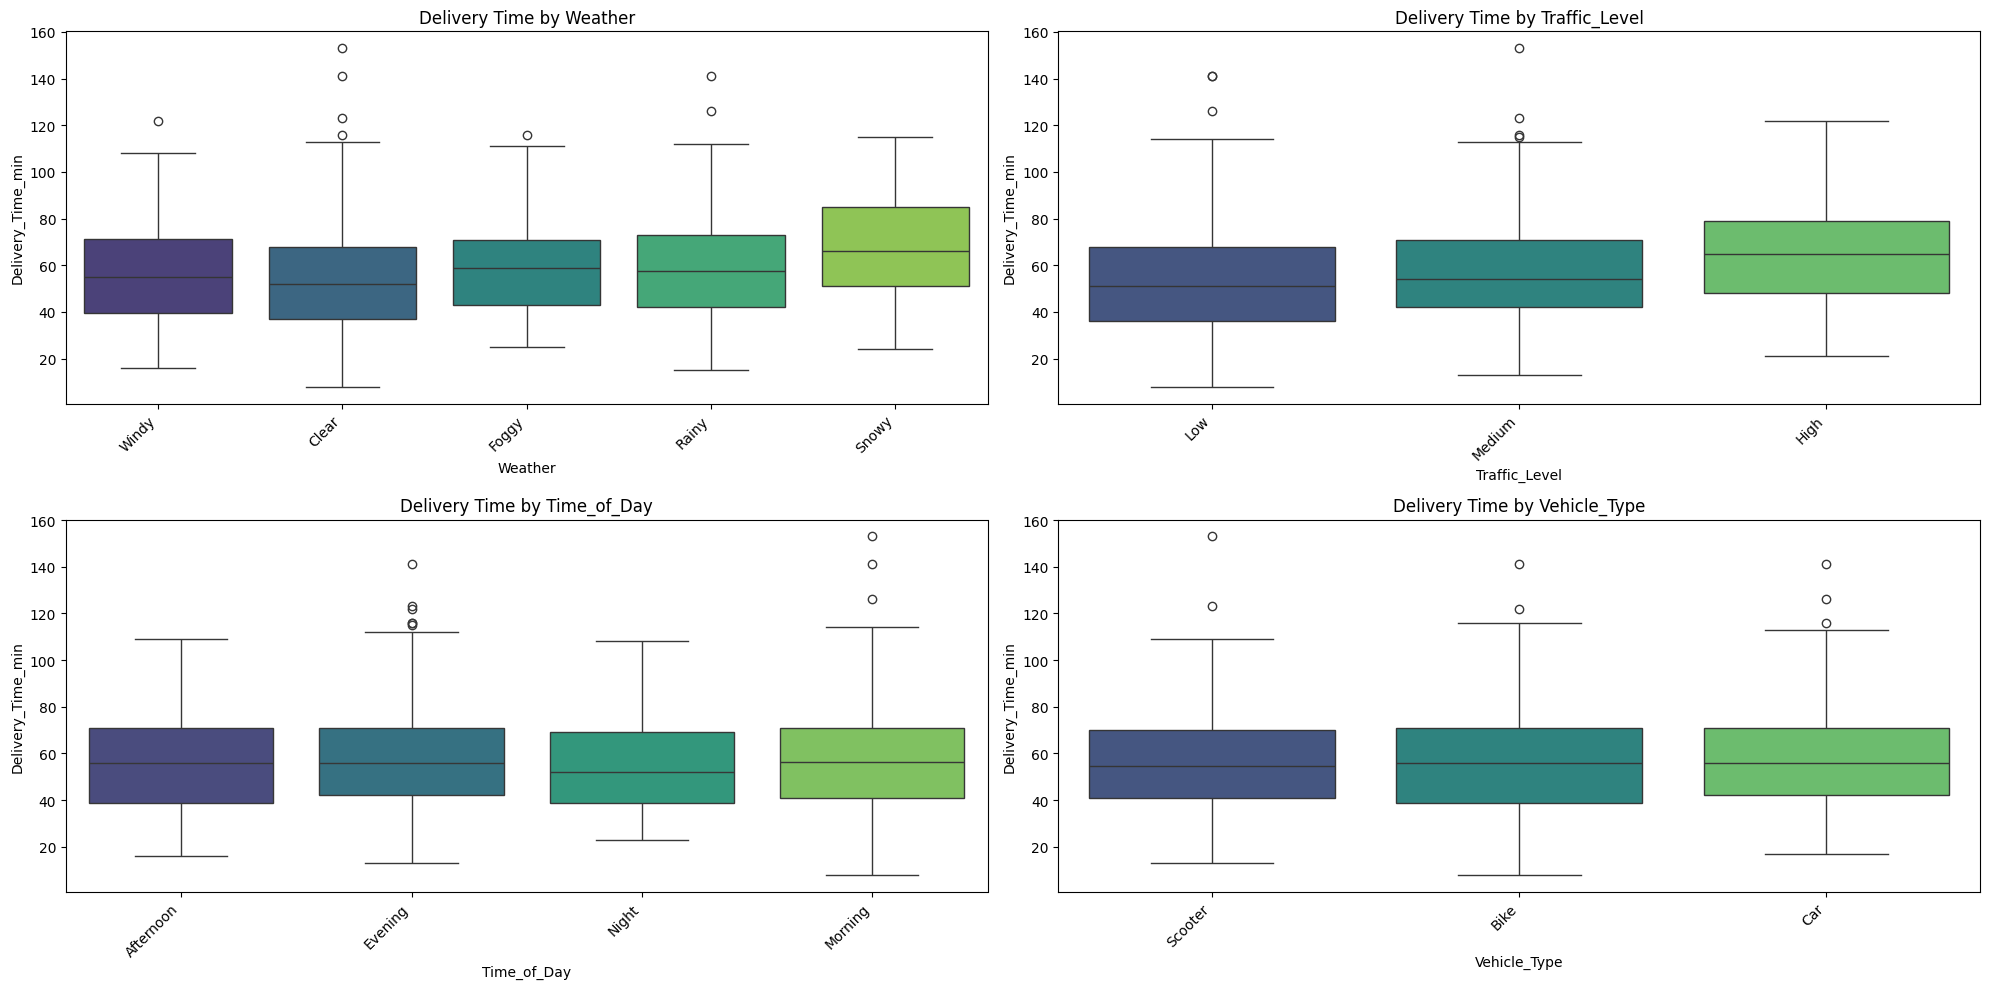

In [10]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(20, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x=col, y='Delivery_Time_min', hue=col, palette='viridis', legend=False)
    plt.title(f'Delivery Time by {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery_Time_min')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Statistical Testing: ANOVA for Categorical Features

To formally assess the significance of categorical features on `Delivery_Time_min`, we'll use one-way ANOVA. This test checks if the means of two or more groups (categories) are significantly different from each other. A low p-value (typically < 0.05) indicates that the differences between the group means are statistically significant, suggesting the categorical feature is important.

In [11]:
from scipy import stats

categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

print('ANOVA Results for Categorical Features vs. Delivery_Time_min:')
print('------------------------------------------------------------')

for col in categorical_cols:
    # Get unique categories
    categories = df[col].unique()

    # Prepare data for ANOVA (list of 'Delivery_Time_min' for each category)
    groups = [df['Delivery_Time_min'][df[col] == cat] for cat in categories]

    # Perform one-way ANOVA
    f_statistic, p_value = stats.f_oneway(*groups)

    print(f'Feature: {col}')
    print(f'  F-statistic: {f_statistic:.2f}')
    print(f'  P-value: {p_value:.3f}')
    if p_value < 0.05:
        print('  Conclusion: Statistically significant (p < 0.05) - this feature likely impacts Delivery_Time_min.')
    else:
        print('  Conclusion: Not statistically significant (p >= 0.05) - this feature may not significantly impact Delivery_Time_min.')
    print('------------------------------------------------------------')

ANOVA Results for Categorical Features vs. Delivery_Time_min:
------------------------------------------------------------
Feature: Weather
  F-statistic: 10.50
  P-value: 0.000
  Conclusion: Statistically significant (p < 0.05) - this feature likely impacts Delivery_Time_min.
------------------------------------------------------------
Feature: Traffic_Level
  F-statistic: 19.75
  P-value: 0.000
  Conclusion: Statistically significant (p < 0.05) - this feature likely impacts Delivery_Time_min.
------------------------------------------------------------
Feature: Time_of_Day
  F-statistic: 0.35
  P-value: 0.792
  Conclusion: Not statistically significant (p >= 0.05) - this feature may not significantly impact Delivery_Time_min.
------------------------------------------------------------
Feature: Vehicle_Type
  F-statistic: 0.59
  P-value: 0.555
  Conclusion: Not statistically significant (p >= 0.05) - this feature may not significantly impact Delivery_Time_min.
-----------------------

### 4. Correlation Heatmap

Let's visualize the correlation between the numerical features and the target variable using a heatmap. This helps us understand the linear relationships present in the dataset.

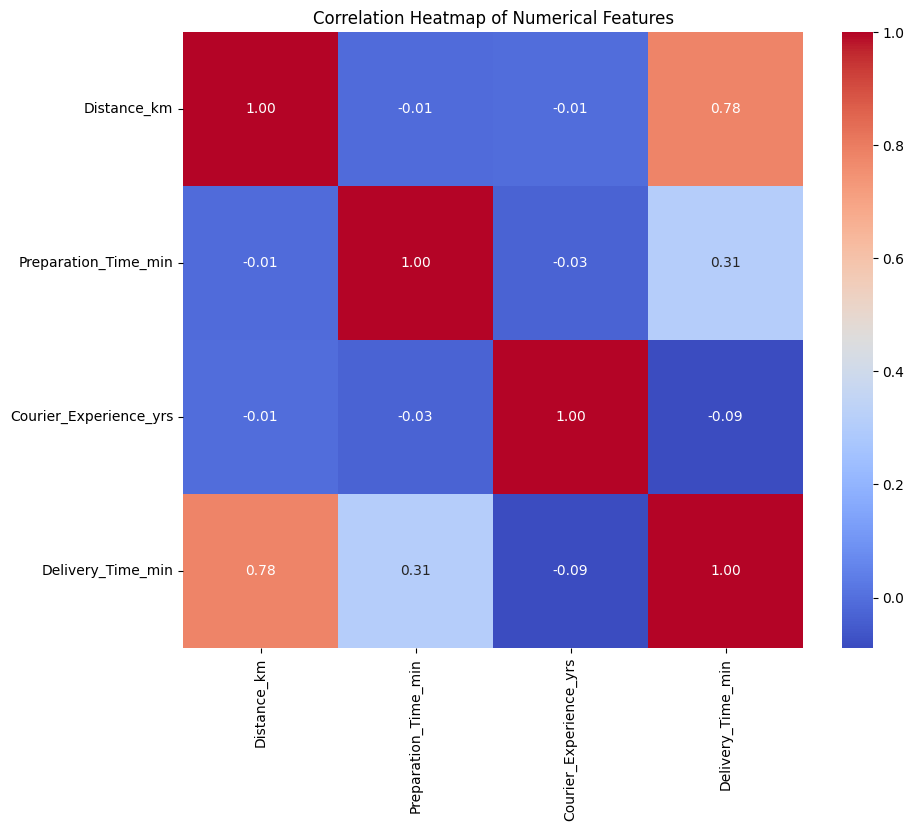

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### 1. Target Variable Analysis: 'Delivery_Time_min'

Let's start by examining the distribution of our target variable, `Delivery_Time_min`. We will use a histogram and a box plot to visualize its spread, central tendency, and identify any outliers.

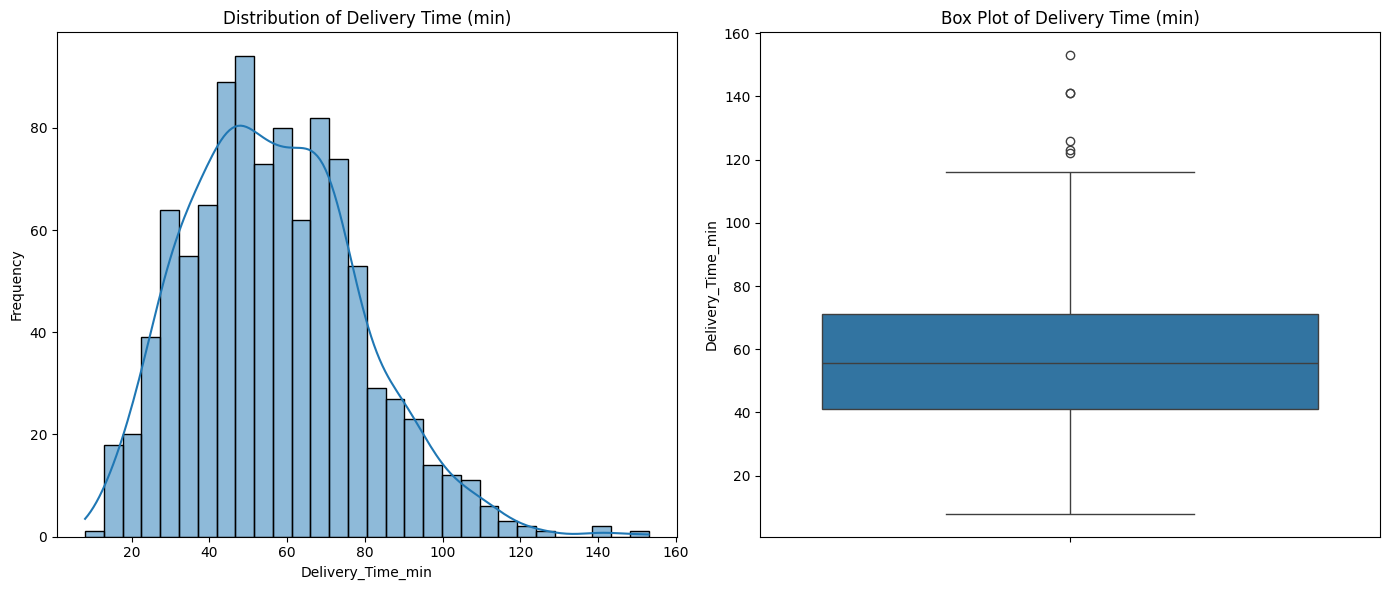

Skewness of Delivery_Time_min: 0.51


In [13]:
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery_Time_min')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (min)')
plt.ylabel('Delivery_Time_min')

plt.tight_layout()
plt.show()

# Check for skewness
print(f"Skewness of Delivery_Time_min: {df['Delivery_Time_min'].skew():.2f}")

### 2. Numerical Features Distribution

Now, let's look at the distribution of other numerical features in the dataset: `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs`.

Skewness of Distance_km: 0.04
Skewness of Preparation_Time_min: 0.03
Skewness of Courier_Experience_yrs: -0.03


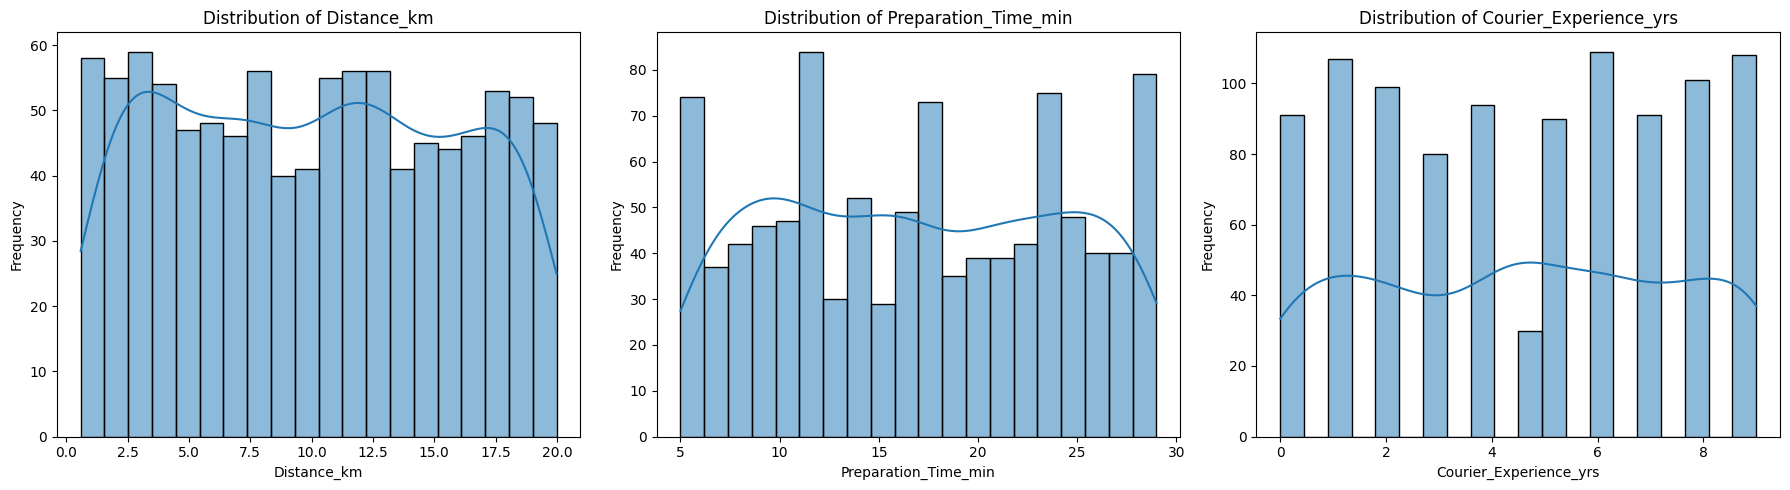

In [14]:
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    print(f"Skewness of {col}: {df[col].skew():.2f}")

plt.tight_layout()
plt.show()

In [15]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

### 6.1 Label Encoding Categorical Features

As requested, we will now apply Label Encoding to our categorical features. This converts each category into a numerical label, which is suitable for tree-based models like Decision Trees and Random Forests.

In [16]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns for Label Encoding
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Create a copy of the DataFrame to apply encoding without modifying the original 'df'
df_encoded = df.copy()

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f"Label mapping for {col}: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

print('\nDataFrame after Label Encoding:')
display(df_encoded.head())

Label mapping for Weather: ['Clear', 'Foggy', 'Rainy', 'Snowy', 'Windy'] -> [0, 1, 2, 3, 4]
Label mapping for Traffic_Level: ['High', 'Low', 'Medium'] -> [0, 1, 2]
Label mapping for Time_of_Day: ['Afternoon', 'Evening', 'Morning', 'Night'] -> [0, 1, 2, 3]
Label mapping for Vehicle_Type: ['Bike', 'Car', 'Scooter'] -> [0, 1, 2]

DataFrame after Label Encoding:


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


In [17]:
from sklearn.model_selection import train_test_split

# Define target variable (y) and features (X) from the encoded DataFrame
y = df_encoded['Delivery_Time_min']
X = df_encoded.drop('Delivery_Time_min', axis=1)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 7)
Shape of X_test: (200, 7)
Shape of y_train: (800,)
Shape of y_test: (200,)


### 7. Decision Tree Regressor Model

Let's train a Decision Tree Regressor model using the default parameters. After training, we will evaluate its performance using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Decision Tree Regressor with default parameters
dtree_model = DecisionTreeRegressor(random_state=42)

# Train the model
dtree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dtree_model.predict(X_test)

# Evaluate the model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = mse_dt**0.5 # Calculate RMSE
r2_dt = r2_score(y_test, y_pred_dt)

print('Decision Tree Regressor Model Performance:')
print(f'  Mean Absolute Error (MAE): {mae_dt:.2f}')
print(f'  Mean Squared Error (MSE): {mse_dt:.2f}')
print(f'  Root Mean Squared Error (RMSE): {rmse_dt:.2f}')
print(f'  R-squared (R2): {r2_dt:.2f}')

Decision Tree Regressor Model Performance:
  Mean Absolute Error (MAE): 10.52
  Mean Squared Error (MSE): 226.84
  Root Mean Squared Error (RMSE): 15.06
  R-squared (R2): 0.49


### 8. Random Forest Regressor Model

Now, let's train a Random Forest Regressor model using the default parameters and evaluate its performance. Random Forests are ensemble models that typically offer better generalization than single Decision Trees.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Random Forest Regressor with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5 # Calculate RMSE
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest Regressor Model Performance:')
print(f'  Mean Absolute Error (MAE): {mae_rf:.2f}')
print(f'  Mean Squared Error (MSE): {mse_rf:.2f}')
print(f'  Root Mean Squared Error (RMSE): {rmse_rf:.2f}')
print(f'  R-squared (R2): {r2_rf:.2f}')

Random Forest Regressor Model Performance:
  Mean Absolute Error (MAE): 7.11
  Mean Squared Error (MSE): 100.34
  Root Mean Squared Error (RMSE): 10.02
  R-squared (R2): 0.78


### 9. Hyperparameter Tuning for Random Forest Regressor using Randomized Search

To further improve the Random Forest model's performance and ensure it generalizes well, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method samples a fixed number of parameter settings from specified distributions, which can be more computationally efficient than `GridSearchCV` while still finding good parameter combinations.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 500),  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'max_depth': randint(10, 50), # Maximum depth of the tree
    'min_samples_split': randint(2, 20),  # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10)  # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter defines how many different settings are sampled
# n_jobs=-1 means use all available processors
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=50, cv=5, n_jobs=-1, scoring='r2', random_state=42)

# Fit the random search to the data
random_search.fit(X_train, y_train)

print("Best parameters found by RandomizedSearchCV:")
print(random_search.best_params_)

print("Best R-squared score found by RandomizedSearchCV:")
print(random_search.best_score_)

# Get the best model
best_rf_model_tuned = random_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_best_rf_tuned = best_rf_model_tuned.predict(X_test)

# Evaluate the best model
mae_best_rf_tuned = mean_absolute_error(y_test, y_pred_best_rf_tuned)
mse_best_rf_tuned = mean_squared_error(y_test, y_pred_best_rf_tuned)
rmse_best_rf_tuned = mse_best_rf_tuned**0.5
r2_best_rf_tuned = r2_score(y_test, y_pred_best_rf_tuned)

print('\nPerformance of the best Random Forest model on the test set (after Randomized Search):')
print(f'  Mean Absolute Error (MAE): {mae_best_rf_tuned:.2f}')
print(f'  Mean Squared Error (MSE): {mse_best_rf_tuned:.2f}')
print(f'  Root Mean Squared Error (RMSE): {rmse_best_rf_tuned:.2f}')
print(f'  R-squared (R2): {r2_best_rf_tuned:.2f}')

Best parameters found by RandomizedSearchCV:
{'max_depth': 39, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 413}
Best R-squared score found by RandomizedSearchCV:
0.7039746887951607

Performance of the best Random Forest model on the test set (after Randomized Search):
  Mean Absolute Error (MAE): 7.21
  Mean Squared Error (MSE): 96.37
  Root Mean Squared Error (RMSE): 9.82
  R-squared (R2): 0.78


### 10. Saving Label Encoders and Best Model

To facilitate deployment and future use in a frontend application, we will save the trained Label Encoders for each categorical feature and the best Random Forest Regressor model obtained from `RandomizedSearchCV` as pickle files.

In [21]:
import pickle
from sklearn.preprocessing import LabelEncoder

# --- Save Label Encoders ---
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
label_encoders = {}

print("Saving Label Encoders...")
for col in categorical_cols:
    le = LabelEncoder()
    # Fit LabelEncoder on the original column to capture all categories
    le.fit(df[col])
    label_encoders[col] = le
    filename = f'label_encoder_{col}.pkl'
    with open(filename, 'wb') as file:
        pickle.dump(le, file)
    print(f"  - Saved {filename}")

# --- Save the Best Random Forest Model ---
# Ensure 'best_rf_model_tuned' is available from the previous RandomizedSearchCV run
if 'best_rf_model_tuned' in locals():
    model_filename = 'best_random_forest_model.pkl'
    with open(model_filename, 'wb') as file:
        pickle.dump(best_rf_model_tuned, file)
    print(f"\nSaving the best Random Forest model to {model_filename}")
else:
    print("\nError: 'best_rf_model_tuned' not found. Please ensure RandomizedSearchCV was run successfully.")

print("\nAll required files have been saved successfully.")


# Example of how to load the files (for demonstration):
# print("\nExample of loading the saved files:")
# with open('label_encoder_Weather.pkl', 'rb') as file:
#     loaded_le_weather = pickle.load(file)
# print(f"Loaded LabelEncoder for Weather: {loaded_le_weather.classes_}")

# with open('best_random_forest_model.pkl', 'rb') as file:
#     loaded_model = pickle.load(file)
# print("Loaded model type:", type(loaded_model))

Saving Label Encoders...
  - Saved label_encoder_Weather.pkl
  - Saved label_encoder_Traffic_Level.pkl
  - Saved label_encoder_Time_of_Day.pkl
  - Saved label_encoder_Vehicle_Type.pkl

Saving the best Random Forest model to best_random_forest_model.pkl

All required files have been saved successfully.
